<a href="https://colab.research.google.com/github/sabrinaangel/ml-dataset-preprocessing/blob/main/python2/TextKlasifikasi/01_TFIDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktek TF-IDF
=============================

In [3]:
import pandas as pd
import numpy as np

In [4]:
dataset = pd.read_csv('clean_dataset_stem.csv',sep=';')

In [5]:
dataset.shape

(902, 10)

In [6]:
dataset.head(3)

,Unnamed: 0.1,Unnamed: 0,Tweet,Sentimen,step01,tokens,final_tokens,step02,finalText_str,ProcessedText
0,0,0,"Cegah mata rantai Covid-19,mari kita dirumah s...",1.0,cegah mata rantai covid mari kita dirumah sa...,"['cegah', 'mata', 'rantai', 'covid', 'mari', '...","['cegah', 'mata', 'rantai', 'covid', 'mari', '...",cegah mata rantai covid mari kita dirumah saja...,cegah mata rantai covid mari kita dirumah saja...,cegah mata rantai covid kita rumah hingga hari...
1,1,1,aku mohon yaAllah semoga wabah covid-19 menghi...,1.0,aku mohon yaallah semoga wabah covid menghil...,"['aku', 'mohon', 'yaallah', 'semoga', 'wabah',...","['aku', 'mohon', 'yaallah', 'semoga', 'wabah',...",aku mohon yaallah semoga wabah covid menghilan...,aku mohon yaallah semoga wabah covid menghilan...,aku mohon yaallah moga wabah covid hilang rama...
2,2,2,Pemprov Papua Naikkan Status Jadi Tanggap Daru...,1.0,pemprov papua naikkan status jadi tanggap daru...,"['pemprov', 'papua', 'naikkan', 'status', 'jad...","['pemprov', 'papua', 'naikkan', 'status', 'jad...",pemprov papua naikkan status jadi tanggap daru...,pemprov papua naikkan status jadi tanggap daru...,pemprov papua naik status jadi tanggap darurat...


In [7]:
dataset_feature = dataset['ProcessedText'].astype(str)

In [8]:
dataset_feature

,ProcessedText
0,cegah mata rantai covid kita rumah hingga hari...
1,aku mohon yaallah moga wabah covid hilang rama...
2,pemprov papua naik status jadi tanggap darurat...
3,covid nyampe prigen mbak hmm hoax
4,nyuruh orang pintar lu aja togog kerumun orang...
...,...
897,seluruh negara dunia alami masa sulit covid ra...
898,covid skripsi disaster selesai mau bgt bljr ma...
899,malam projek benda bincang malam fb satu belia...
900,pontang panting koyak covid


In [9]:
dataset_label = dataset['Sentimen']

In [10]:
dataset_label

,Sentimen
0,1.0
1,1.0
2,1.0
3,0.0
4,-1.0
...,...
897,1.0
898,1.0
899,0.0
900,-1.0


# cek distribusi label

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

/tmp/ipykernel_1912/1470841120.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset_label, label=f'target, skew: {dataset_label.skew():.2f}')


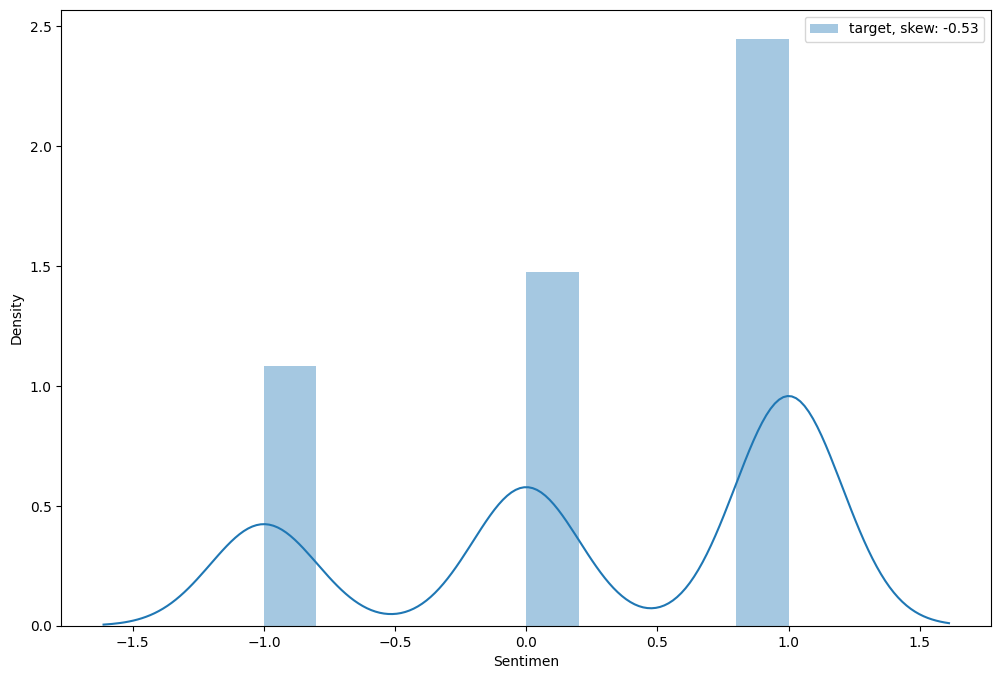

In [12]:
# Visualizing the target variable
plt.figure(figsize=(12,8))
sns.distplot(dataset_label, label=f'target, skew: {dataset_label.skew():.2f}')
plt.legend(loc='best')
plt.show()

In [13]:
dataset_label.value_counts()

,count
Sentimen,
1.0,441
0.0,266
-1.0,195


# TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [15]:
vectorizer = TfidfVectorizer()

In [16]:
positive_reviews = dataset[(dataset["Sentimen"] == 1)]
negative_reviews = dataset[(dataset["Sentimen"] == -1)]
neutral_reviews = dataset[(dataset["Sentimen"] == 0)]

In [17]:
positive_reviews.head()

,Unnamed: 0.1,Unnamed: 0,Tweet,Sentimen,step01,tokens,final_tokens,step02,finalText_str,ProcessedText
0,0,0,"Cegah mata rantai Covid-19,mari kita dirumah s...",1.0,cegah mata rantai covid mari kita dirumah sa...,"['cegah', 'mata', 'rantai', 'covid', 'mari', '...","['cegah', 'mata', 'rantai', 'covid', 'mari', '...",cegah mata rantai covid mari kita dirumah saja...,cegah mata rantai covid mari kita dirumah saja...,cegah mata rantai covid kita rumah hingga hari...
1,1,1,aku mohon yaAllah semoga wabah covid-19 menghi...,1.0,aku mohon yaallah semoga wabah covid menghil...,"['aku', 'mohon', 'yaallah', 'semoga', 'wabah',...","['aku', 'mohon', 'yaallah', 'semoga', 'wabah',...",aku mohon yaallah semoga wabah covid menghilan...,aku mohon yaallah semoga wabah covid menghilan...,aku mohon yaallah moga wabah covid hilang rama...
2,2,2,Pemprov Papua Naikkan Status Jadi Tanggap Daru...,1.0,pemprov papua naikkan status jadi tanggap daru...,"['pemprov', 'papua', 'naikkan', 'status', 'jad...","['pemprov', 'papua', 'naikkan', 'status', 'jad...",pemprov papua naikkan status jadi tanggap daru...,pemprov papua naikkan status jadi tanggap daru...,pemprov papua naik status jadi tanggap darurat...
6,6,6,"Selamat pagi, hari jum'at. Jum'at keempat di k...",1.0,selamat pagi hari jumat jumat keempat di kala ...,"['selamat', 'pagi', 'hari', 'jumat', 'jumat', ...","['selamat', 'pagi', 'hari', 'jumat', 'jumat', ...",selamat pagi hari jumat jumat keempat di kala ...,selamat pagi hari jumat jumat keempat di kala ...,selamat pagi hari jumat jumat empat kala pande...
7,7,7,"Hikmah di balik musibah covid-19, smg para pej...",1.0,hikmah di balik musibah covid smg para pejab...,"['hikmah', 'di', 'balik', 'musibah', 'covid', ...","['hikmah', 'di', 'balik', 'musibah', 'covid', ...",hikmah di balik musibah covid smg para pejabat...,hikmah di balik musibah covid smg para pejabat...,hikmah balik musibah covid smg jabat perintah ...


In [18]:
Positive_tf_idf_vect = TfidfVectorizer(ngram_range=(1,2))
Positive_tf_idf = Positive_tf_idf_vect.fit_transform(positive_reviews["ProcessedText"].values)

In [19]:
Positive_tf_idf.shape

(441, 7781)

In [20]:
features = Positive_tf_idf_vect.get_feature_names_out()

In [21]:
idfValues = Positive_tf_idf_vect.idf_

In [22]:
d = dict(zip(features, 9 - idfValues))

In [23]:
sortedDict = sorted(d.items(), key = lambda d: d[1], reverse = True)

In [24]:
for i in range(200):
    print(sortedDict[i])

('covid', np.float64(7.97247532660991))
('virus', np.float64(6.083077387817939))
('cegah', np.float64(6.067573201281974))
('sebar', np.float64(6.0195639820956135))
('corona', np.float64(5.934041808657451))
('moga', np.float64(5.878982031474424))
('sama', np.float64(5.878982031474424))
('rumah', np.float64(5.737331514411396))
('yg', np.float64(5.737331514411396))
('wabah', np.float64(5.669890233615864))
('semua', np.float64(5.597569572036238))
('masyarakat', np.float64(5.464038179411716))
('perintah', np.float64(5.464038179411716))
('sehat', np.float64(5.464038179411716))
('tangan', np.float64(5.464038179411716))
('jaga', np.float64(5.405197679388782))
('bantu', np.float64(5.342677322407448))
('virus corona', np.float64(5.342677322407448))
('indonesia', np.float64(5.309887499584457))
('laku', np.float64(5.309887499584457))
('satu', np.float64(5.309887499584457))
('segera', np.float64(5.309887499584457))
('wabah covid', np.float64(5.309887499584457))
('beri', np.float64(5.275985947908776

In [25]:
# !pip3 install wordcloud

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plot

In [27]:
def PlotWordCloud(frequency):
    worcloudPlot = WordCloud(background_color="white", width=1500, height=1000)
    worcloudPlot.generate_from_frequencies(frequencies=frequency)
    plot.figure(figsize=(15,10))
    plot.imshow(worcloudPlot, interpolation="bilinear")
    plot.axis("off")
    plot.show()

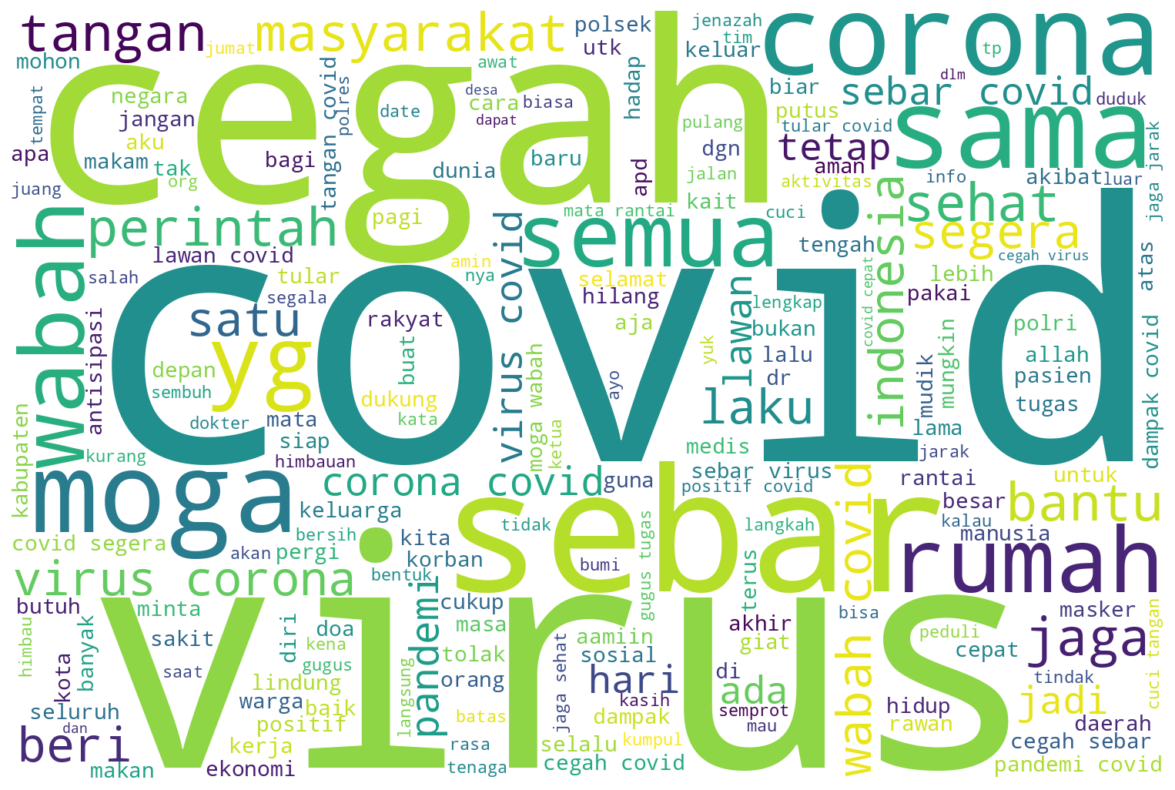

In [28]:
PlotWordCloud(d)

# silakan lakukan untuk netral dan negative